In [70]:
# Had to fix it using claude. Stupid error.

# Make project root importable so we can import eda/...
import sys, os
ROOT = os.path.abspath(os.path.join(os.getcwd(), ".."))
if ROOT not in sys.path:
    sys.path.insert(0, ROOT)

from importlib import reload
from eda import eda_utils as eda_utils
reload(eda_utils)  # so edits to eda_utils.py are picked up

# sanity check
import inspect
print("eda_utils at:", eda_utils.__file__)
import importlib, inspect
import eda.eda_utils as eda_utils
importlib.reload(eda_utils)          # picks up your saved changes
# should show: (img, band_labels, text_label, label_each_band, cmocean)
from eda.eda_utils import load_data, replace_with_nan, minmax_stretch, percentile_stretch, plot_band, calculate_band_statistics, standardize, histogram_before_after_standardization_z_score,show_band_vs_z, correlation_matrix, correlation_plot
importlib.reload(eda_utils)
import copy
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
import cmocean as cmo
import seaborn as sns
from pandas import DataFrame
from sklearn.discriminant_analysis import StandardScaler
import spectral as spy
import re
from PIL import Image
import scipy.io as sio
import copy
import sys, platform
print(sys.executable)
print(platform.python_version())

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.cross_decomposition import PLSRegression

from sklearn.metrics import accuracy_score, precision_recall_fscore_support
from sklearn.metrics import roc_curve, auc
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, confusion_matrix
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score


eda_utils at: /Users/wangtiles/Applcns_of_ML_remote_sensing/eda/eda_utils.py
/Library/anaconda3/envs/rs-ml/bin/python
3.11.11


Problem 1: Classification
Binary & Multi-Class Classification
Remote sensing data: PaviaU.mat & PaviaU_gt.mat
PaviaU dataset = hyperspectral dataset | Sensor = reflective optics system imaging spectrometer (ROSIS-3)
Image = 610 * 340 pixels with 103 spectral bands.
The dataset is imbalanced.
The sensor collects between 430-960 nm in 5 nm spectral spacing.
"""
"""
Problem 1a)
Perform EDA.
Explain what are the important aspect of this dataset that needs to be explored before delving into 
solving the problem.
classes = 9 | imbalanced.
- check shape, dtype, unique labels
- then check for nulls
- look at the image, do they make sense visually
- describe the numeric distr. per feature/band
- then explore the relationships among the features: correlation and spot for redundancies.
- and then look into class distribution, imabalnce, and what the potential sampling issues might be.


In [8]:
paviaU_X_data = sio.loadmat('/Users/wangtiles/Applcns_of_ML_remote_sensing/ml/data_downloaded_HW3/PaviaU.mat')
paviaU_y_data = sio.loadmat('/Users/wangtiles/Applcns_of_ML_remote_sensing/ml/data_downloaded_HW3/PaviaU_gt.mat')
print("datatype: ",type(paviaU_X_data),"\nkeys: ", paviaU_X_data.keys(), "\nx/feature_inputs/img = ", paviaU_X_data['paviaU'].shape)
print("datatype: ",type(paviaU_y_data),"\nkeys: ", paviaU_y_data.keys(), "\ny/features/classes/ground_truth/gt = ", paviaU_y_data['paviaU_gt'].shape)

# image shape, data type and ground truth labels:
img = paviaU_X_data['paviaU'].astype(np.float32)
gt = paviaU_y_data['paviaU_gt'].astype(np.float32)
H, W, Bands = img.shape
print(f"Image shape = {H, W, Bands}")
print(f"Ground truth shape = {gt.shape}")
print(f"Data type = {img.dtype}, Label type: {gt.dtype}")
print(f"Unique GT labels = {np.unique(gt)}")

# replace missing values with nans | and checking out the min/max reflectance values
img_nan = replace_with_nan(img, no_data_value=0)
print("no. of Nans = ", np.isnan(img_nan).sum())
print("min/max reflectance values = ", np.nanmin(img_nan), ", ",np.nanmax(img_nan))


# I shall remove the background pixels where gt was 0
mask = (gt!=0)
# mask
# reshaping the pixels as rows and bands as columns
X = img_nan[mask].reshape(-1, img_nan.shape[-1])
Y = gt[mask].ravel()
print("after I remove the background: ", X.shape,", ",Y.shape)
# dropping the Nan rows
mask_finite = np.all(np.isfinite(X), axis = 1)
X_no_nan = X[mask_finite]
Y_no_nan = Y[mask_finite]
print("after dropping the nans: ", X_no_nan.shape, ", ", Y_no_nan.shape)


# studying the class imbalance
classes, counts = np.unique(Y_no_nan, return_counts=True)
print("class counts:")
for c, n in zip(classes, counts):
    print(f"class {c}: {n}")
# print(classes)
# print(counts)



datatype:  <class 'dict'> 
keys:  dict_keys(['__header__', '__version__', '__globals__', 'paviaU']) 
x/feature_inputs/img =  (610, 340, 103)
datatype:  <class 'dict'> 
keys:  dict_keys(['__header__', '__version__', '__globals__', 'paviaU_gt']) 
y/features/classes/ground_truth/gt =  (610, 340)
Image shape = (610, 340, 103)
Ground truth shape = (610, 340)
Data type = float32, Label type: float32
Unique GT labels = [0. 1. 2. 3. 4. 5. 6. 7. 8. 9.]
no. of Nans =  3141
min/max reflectance values =  1.0 ,  8000.0
after I remove the background:  (42776, 103) ,  (42776,)
after dropping the nans:  (42599, 103) ,  (42599,)
class counts:
class 1.0: 6631
class 2.0: 18563
class 3.0: 2099
class 4.0: 3030
class 5.0: 1345
class 6.0: 5021
class 7.0: 1330
class 8.0: 3682
class 9.0: 898


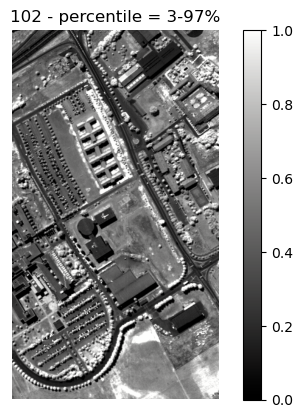

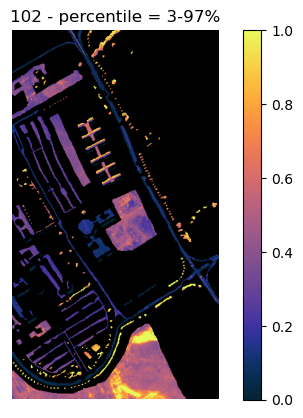

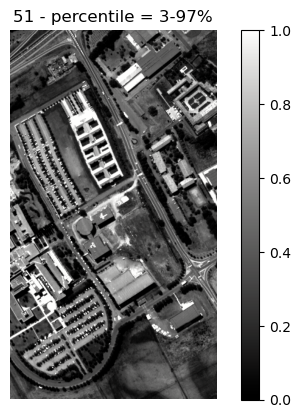

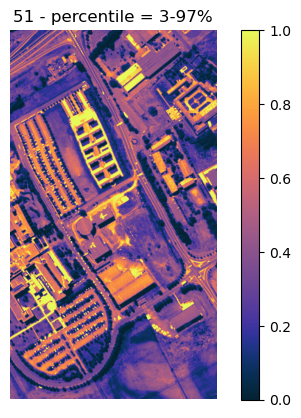

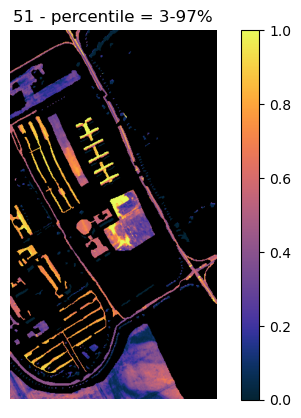

In [9]:
# plotting a band to look at image:
img_masked = img_nan.copy()
img_masked[gt == 0] = np.nan # I am removing the background pixels where the reflectance was 0, hence masking with gt == 0
plot_band(img_nan, labels = np.arange(img_nan.shape[-1]), band_i=102, cmap_name="gray")
plot_band(img_masked, labels = np.arange(img_masked.shape[-1]), band_i=102, cmap_name="thermal")
plot_band(img_nan, labels = np.arange(img_nan.shape[-1]), band_i=51, cmap_name="gray")
plot_band(img_nan, labels = np.arange(img_nan.shape[-1]), band_i=51, cmap_name="thermal")
plot_band(img_masked, labels = np.arange(img_masked.shape[-1]), band_i=51, cmap_name="thermal", title = "")
# plot_band(img_nan, labels = np.arange(img_nan.shape[-1]), band_i=1, cmap_name="thermal")
# plot_band(img_masked, labels = np.arange(img_masked.shape[-1]), band_i=1, cmap_name="phase")


Observations: 
- the scene clearly shows urban structures (roads, buildings) and open fields.
- the bottom black regions appear because I masked background pixels (gt==0) and set them to NaN; that’s expected — those are unlabeled areas removed intentionally.
- higher reflectance areas (yellow/orange) likely correspond to man-made surfaces or bare soil, while darker areas (purple/blue) are vegetated or shaded.


   label        mean  median     q1      q3         std      skew       kurt
0      0  926.276282   857.0  649.0  1111.0  443.662881  2.054910  11.943708
1      1  851.460995   763.0  556.0  1046.0  467.687745  2.265210  13.060813
2      2  801.778462   695.0  484.0  1015.0  492.875569  2.404246  13.948814
3      3  811.145220   691.0  474.0  1037.0  526.676643  2.577905  15.163091
4      4  830.815016   693.0  480.0  1059.0  555.116298  2.770706  16.439634


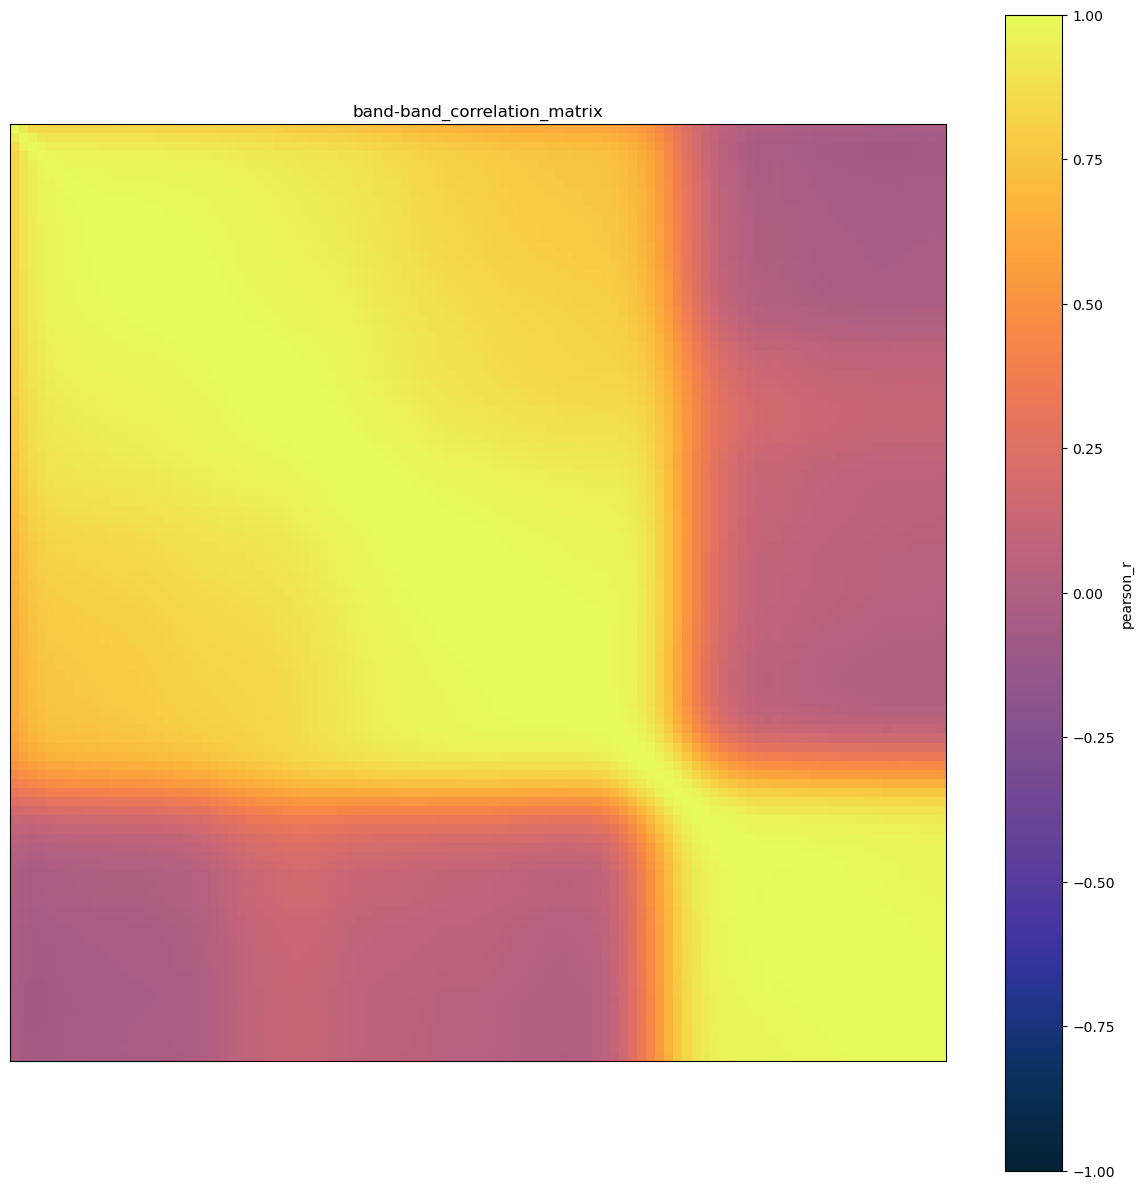

In [10]:
# band statistics
band_stats = calculate_band_statistics(img_nan, labels=np.arange(img_nan.shape[-1]))
print(band_stats.head())
# band_stats.to_csv('band_desc_stats_HW3_prob1.csv') # saved it

# correlation matrix
corr_mat = correlation_matrix(img_nan, band_labels=None,text_label=False, label_each_band=False, yes_show=True, cmocean="thermal")



Observations from correlation matrix:
- upper left portion in yellow shows high positive correlation between most bands.
- this means that the reflectance values or the signal changes smoothly across the spectrum.
- these yellow blocks represent wavelength regions like visible ones whose values would be similar to each other.
- the pinkish-purple blocks where the correlation is low positive values represents bands where the transition happens between visible and near-infrared regions.
- overall this confirms strong band redundancy. So we don't have to use all the 103 bands together. For modeling we can just select representative bands or apply PCA to help with reducing dimensionality and avoid multicollinearity.


Problem 1b)
Binary Classification using logistic regression: Vegetation vs Non-vegetation.
- Veg_class = class 2(meadows) + 4(trees) = 21593 samples
- Non_veg_class = all others = 21006
- Roughly(balanced) 50:50 with 587 more samples of vegetation. Very negligible class imbalance.
- 5 representative bands to be selected as instructed:
    - blue = 480 nm
    - green = 560 nm
    - red = 665 nm
    - red-edge = 705 nm
    - NIR = 842 nm
    Need to find the approx near-indices.
- train-test split: 70:30 of train and test. Will conduct simple 1:1 stratification of both the classes. 
- run a log reg:
    - standardize the features before fitting
    - predict on both train and test
    - compute the classification metrics:
        - mean accuracy & mean per-class (accuracy, precision, recall, F1)
        - ROC curve
        - AUC curve on the test set.
- interpret the results.


In [11]:
# making binary labels for veg and non veg class.
# veg = class 2 + class 4, everything else = non_veg
y_bin = (Y_no_nan == 2) | (Y_no_nan == 4) # bool mask to set True when meadows or trees class
y_bin = y_bin.astype(int) # cast with int to avoid dtype errors

# counting the unique values to get the classes and their resp counts to check for balance
classes, counts = np.unique(y_bin, return_counts = True)
print("binary classes:",  classes) # 0 -> non_veg , 1 -> veg
print("binary counts:", counts)



binary classes: [0 1]
binary counts: [21006 21593]


In [12]:
# selecting the 5 band indices
# wavelengths are linearly spaced across the 103 bands
centers = np.linspace(430.0, 960.0, Bands)
features = np.array([480.0,560.0, 665.0, 705.0, 842.0]) # blue, green, red, red-edge, NIR
# nearest band indices to each feature wavelength
ids = [int(np.argmin(np.abs(centers - f))) for f in features]
print("feature (nm) : ", features)
print("picked centers : ", centers[ids])
print("band ids : ", ids) 



feature (nm) :  [480. 560. 665. 705. 842.]
picked centers :  [481.96078431 559.90196078 663.82352941 705.39215686 840.49019608]
band ids :  [10, 25, 45, 53, 79]


In [13]:
# slicing the 5 selected bands and doing train-test stratified split
X5 = X_no_nan[:, ids] # slicing to only 5 selected band ids
X_train, X_test, y_train, y_test = train_test_split(X5, y_bin, test_size=0.30, random_state=0, stratify=y_bin)
print("train shape: ", X_train.shape, "test shape: ", X_test.shape)

tr_classes, tr_counts = np.unique(y_train, return_counts = True)
te_classes, te_counts = np.unique(y_test, return_counts=True)
print("train class counts:", tr_classes, tr_counts)
print("test class counts :", te_classes, te_counts) # the veg samples exceed non_veg by 170 samples. Fairly negligible imbalance. 



train shape:  (29819, 5) test shape:  (12780, 5)
train class counts: [0 1] [14704 15115]
test class counts : [0 1] [6302 6478]


In [14]:
# z-score by columns using train stats only (mu, sigma from train) for standardization
mu = np.mean(X_train, axis=0)
sigma = np.std(X_train, axis=0)
sigma[sigma == 0] = 1.0  # avoiding division by zero

X_tr_s = (X_train - mu) / sigma
X_te_s = (X_test - mu) / sigma


In [15]:
# log reg and metrics
clf = LogisticRegression(max_iter=1000, solver = "lbfgs")
clf.fit(X_tr_s, y_train)

y_train_pred = clf.predict(X_tr_s)
y_test_pred = clf.predict(X_te_s)

acc_train = accuracy_score(y_train,y_train_pred)
acc_test = accuracy_score(y_test, y_test_pred)
print("accuracy train: ", acc_train)
print("accuracy test: ", acc_test)

# getting per class metrics for train and test sets
p_tr, r_tr, f1_tr, _ = precision_recall_fscore_support(y_train, y_train_pred, average=None, zero_division=0 )
p_te, r_te, f1_te, _ = precision_recall_fscore_support(y_test, y_test_pred, average=None, zero_division=0)
# getting average across both classes for train and test sets to get an overall sense of the performance
p_tr_macro, r_tr_macro, f1_tr_macro, _ = precision_recall_fscore_support(y_train, y_train_pred, average="macro", zero_division=0)
p_te_macro, r_te_macro, f1_te_macro, _ = precision_recall_fscore_support(y_test, y_test_pred, average="macro", zero_division=0)
# train metrics
print("train per-class precision: ", p_tr)
print("train per-class recall: ", r_tr)
print("train per-class f1 score: ", f1_tr)
print("train macro metrics (mean per-class) = P, R, F1 : ", p_tr_macro, r_tr_macro, f1_tr_macro)
# test metrics
print("test per-class precision: ", p_te)
print("test per-class recall: ", r_te)
print("test per-class f1 score: ", f1_te)
print("test macro metrics (mean per-class) = P, R, F1 : ", p_te_macro, r_te_macro, f1_te_macro)


# ROC AUC curves
# collecting predicted prob of belonging to vegetation class (1)
y_te_prob = clf.predict_proba(X_te_s)[:, 1]
# computing the fpr, tpr, and threshold values required for ROC plot
# we compare the true labels y_test with the predicted probabilities y_te_prob
fpr, tpr, thr = roc_curve(y_test, y_te_prob)
# calculate area under that ROC curve (AUC). If higher, better model discrimnation between the two classes
auc_test = auc(fpr, tpr)



accuracy train:  0.9021093933398169
accuracy test:  0.903755868544601
train per-class precision:  [0.95087612 0.8640597 ]
train per-class recall:  [0.84514418 0.95752564]
train per-class f1 score:  [0.89489792 0.90839479]
train macro metrics (mean per-class) = P, R, F1 :  0.9074679102764546 0.9013349076197466 0.9016463564825885
test per-class precision:  [0.95448029 0.86444444]
test per-class recall:  [0.84512853 0.96079037]
test per-class f1 score:  [0.89648207 0.91007457]
test macro metrics (mean per-class) = P, R, F1 :  0.9094623655913978 0.9029594490112716 0.9032783230154274


Inferences:
- Accuracy of train and test is very close (~ 0.90). Good generalization, no overfitting or underfitting.
- Mean per-class metrics on the TEST set:
    - Precision = 0.909
    - Recall = 0.902
    - F1 score = 0.903
    Balanced performance across both the classes.
- Non-Veg | class 0 (TEST set):
    - Precision = 0.954 : We are almost always right when we predict something as "non-veg"
    - Recall = 0.845 : We tend to miss some non-veg class samples and mislabel it as veg.
    - Explanation = model prefers to avoid false alarms here. It labels a sample as non-veg carefully.
- Veg | class 1 (TEST set):
    - Precision = 0.864 : False positives are more here. True non-veg sample is labelled sometimes as veg.
    - Recall = 0.960 : We tend to catch most of the true veg samples and correctly label them.
    - Explanation = model is clearly recall-heavy for vegetation. It is good at finding veg, and may sometimes over predict. I think the slight imbalance in the training set could be a reason of such performance.
- The classifier leans towards finding vegetation (high recall of 0.96) even if it sometimes tags non-veg as veg (false positives) (precision of 0.86).
- For the non-veg class, the model is more precise (~0.95) but it tends to miss some true non-veg and mislabels them as veg (recall of 0.85).
- Since the dataset is roughly balanced, the accuracy is almost equal to macro-f1 (~.90). 
- How would I phrase the precision and recall for veg class:
    - Precision (veg class) = of all pixels predicted veg, 86% are actually veg.
    - Recall (veg class) = of all actual veg pixels, 96% of them were found correctly.
    - It's the opposite for the non-veg class.

With 5 feature bands and the log reg classifier, the model achieves a 0.90 macro f1 on a roughly balanced veg vs non-veg task. Prefers high recall for vegetation at the cost of some false positive veg on non-veg. I think this recall-heavy behavior likely comes from the fact that NIR+red-edge bands dominate the separation between the classes. If some non-veg is bright, it could lead an incorrect veg labelling. But the Train/test scores indicate good generalization, and the spectral band choice is sufficient enough for good classification.


Problem 1c)
Multi-class Classification using XGBoost: all 9 classes (0 is removed).
- Reusing the above selected 5 bands as features.
- building a stratified 70/30 train/test split on the 9 class labels.
- since xgboost is a bunch of decision trees, no need to standardize the data here. Usually I would standardize, if I were to use multiple types of algorithms, just to keep it clean, but since we are just checking out how multi-class classification works, I won't do it.
- will fit a basic xgboost model. will choose the multi:softprob objective. Will not be doing any hyperparameter tuning since it is a fairly simple classification.
- Evaluation metrics to be the same as log reg's.
- Only addition would be to showcase the confusion matrix and basic feature importances. 
- My class imbalance handling strategy:
    - first with no-balancing. (strategy A)
    - next will use the sample weights to get the inverse class frequency for training. (strategy B)
    - And showcase the metrics on the natural test set, and the balanced test set which will be downsampled.
- Compare the performance with and without balancing.
- And finally discuss which classes are confused and why. (classes with less samples should be more confused. And also classes which were trained on downsampled data.)



In [22]:
# classes 1 to 9
y9 = Y_no_nan.astype(int)
y9_0 = y9 - 1 # I came across valuerror when running the xgboost cell. It takes default 0 to 8 instead of 1 to 9 as class names. So just changing it here.
assert y9_0.min() == 0 and y9_0.max() == 8 # simple assertion
classes, counts = np.unique(y9, return_counts=True) # checking each class and no. of samples
print("the 9-classes and counts:")
for c, n in zip(classes, counts):
    print(c,n)

the 9-classes and counts:
1 6631
2 18563
3 2099
4 3030
5 1345
6 5021
7 1330
8 3682
9 898


In [17]:
# reusing the same 5 bands as before
centers = np.linspace(430.0, 960.0, Bands)
features = np.array([480.0,560.0, 665.0, 705.0, 842.0]) # blue, green, red, red-edge, NIR
# nearest band indices to each feature wavelength
ids = [int(np.argmin(np.abs(centers - f))) for f in features]
print("feature (nm) : ", features)
print("picked centers : ", centers[ids])
print("band ids : ", ids) 

X5 = X_no_nan[:, ids] # slicing to only 5 selected band ids
print("X5 shape: ", X5.shape)

feature (nm) :  [480. 560. 665. 705. 842.]
picked centers :  [481.96078431 559.90196078 663.82352941 705.39215686 840.49019608]
band ids :  [10, 25, 45, 53, 79]
X5 shape:  (42599, 5)


In [24]:
# stratified split for all 9 classes (train/test split)
X_tr, X_te, y_tr, y_te = train_test_split(X5, y9_0, test_size=0.30,random_state=0,stratify=y9_0)
print("train: ", X_tr.shape)
print("test: ", X_te.shape)

# checking the per class counts in the split like before
def print_counts(name, y):
    c,n = np.unique(y,return_counts=True)
    print(name,"class counts: ")
    for a, b in zip(c,n):
        print(a, b)
print_counts("train", y_tr)
print_counts("test", y_te)

train:  (29819, 5)
test:  (12780, 5)
train class counts: 
0 4642
1 12994
2 1469
3 2121
4 941
5 3515
6 931
7 2577
8 629
test class counts: 
0 1989
1 5569
2 630
3 909
4 404
5 1506
6 399
7 1105
8 269


baseline XGB accuracy train:  0.9326939199839028
baseline XGB accuracy test:  0.8495305164319249

baseline TRAIN macro P/R/F1:  0.9508920110576169 0.9230958141170608 0.9334742883743474
baseline TEST  macro P/R/F1:  0.8459179315685953 0.8164311713075235 0.8274907454070504

confusion matrix (test, baseline):
 [[1783    6   54    0    3   11   79   53    0]
 [   1 5294    1   73    0  199    0    1    0]
 [  55    2  362    0    0    5    2  204    0]
 [   0  114    0  792    0    3    0    0    0]
 [   0    0    1    0  403    0    0    0    0]
 [   3  737    2    2    0  754    0    8    0]
 [  95    0    5    0    0    0  294    5    0]
 [  30    4  146    0    0   13    6  906    0]
 [   0    0    0    0    0    0    0    0  269]]


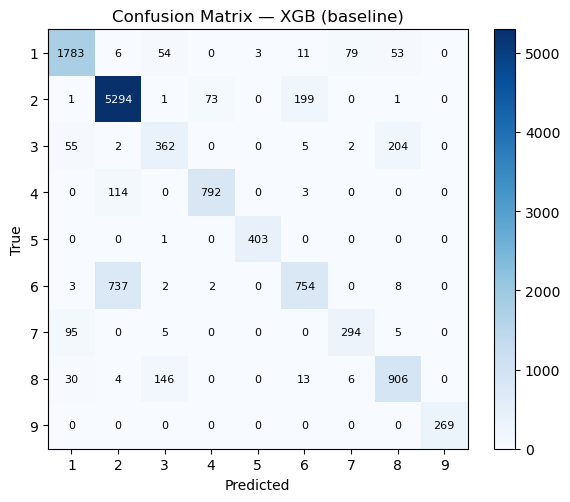

feature importances (gain): [0.24752949 0.13591722 0.14775224 0.18828529 0.28051573]


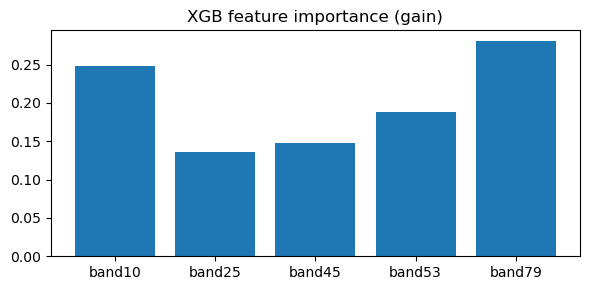

In [38]:
# baseline XGBoost | no balancing. 
# stratified split for all 9 classes (train/test split)

xgb_base = XGBClassifier(
    objective="multi:softprob",
    num_class=9,
    n_estimators=300, 
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_lambda=1.0,
    random_state=0, # i hate 42
    n_jobs=-1, # using all cores
    eval_metric="mlogloss" # standard metric for classification
)

xgb_base.fit(X_tr, y_tr)

# all the predictions
y_tr_pred = xgb_base.predict(X_tr)
y_te_pred = xgb_base.predict(X_te)

# overall accuracy
acc_tr = accuracy_score(y_tr, y_tr_pred)
acc_te = accuracy_score(y_te, y_te_pred)
print("baseline XGB accuracy train: ", acc_tr)
print("baseline XGB accuracy test: ", acc_te)

# per-class metrics and macro averages (mean per-class)
p_tr, r_tr, f1_tr, _ = precision_recall_fscore_support(y_tr, y_tr_pred,average=None, zero_division=0)
p_te, r_te, f1_te, _ = precision_recall_fscore_support(y_te, y_te_pred,average=None, zero_division=0)

p_tr_macro, r_tr_macro, f1_tr_macro, _ = precision_recall_fscore_support(y_tr, y_tr_pred, average="macro",zero_division=0)
p_te_macro, r_te_macro, f1_te_macro, _ = precision_recall_fscore_support(y_te, y_te_pred, average="macro",zero_division=0)

print("\nbaseline TRAIN macro P/R/F1: ", p_tr_macro, r_tr_macro, f1_tr_macro)
print("baseline TEST  macro P/R/F1: ", p_te_macro, r_te_macro, f1_te_macro)

# confusion matrix on test set
cm_base = confusion_matrix(y_te, y_te_pred, labels=np.arange(9))

print("\nconfusion matrix (test, baseline):\n", cm_base)

# display 1 to 9 on the axes instead of 0 to 8 
display_labels = np.arange(1, 10)

# confusion matrix heatmap with text labels
plt.figure(figsize=(6,5))
plt.imshow(cm_base, cmap="Blues")
plt.title("Confusion Matrix — XGB (baseline)")
plt.xlabel("Predicted")
plt.ylabel("True")
# axis labels (1–9 for display)
plt.xticks(ticks=np.arange(9), labels=display_labels)
plt.yticks(ticks=np.arange(9), labels=display_labels)
# add colorbar
plt.colorbar()
# overlay the numeric values
for i in range(cm_base.shape[0]):
    for j in range(cm_base.shape[1]):
        val = cm_base[i, j]
        color = "white" if cm_base[i, j] > cm_base.max()/2 else "black" # labelling appropriately
        plt.text(j, i, f"{val}", ha="center", va="center", color=color, fontsize=8)
plt.tight_layout()
plt.show()

# feature importance from XGBoost (gain)
# the importance order follows the input features (our 5 bands)
importances = xgb_base.feature_importances_
print("feature importances (gain):", importances)

plt.figure(figsize=(6,3))
plt.bar(range(len(importances)), importances)
plt.xticks(range(len(importances)), [f"band{b}" for b in ids])
plt.title("XGB feature importance (gain)")
plt.tight_layout()
plt.show()

Quick inference for baseline performance:
- Accuracy for train(0.93) is slightly greater than test(0.85). Can tighten this gap it more by reducing number of trees (n_estimators) to somewhere 100-150. But it's negligible overfitting.
- Macro: P 0.846 / R 0.816 / F1 0.827
    - Uneven per-class performance is pulling down the recall.
- Feature Importance (gain):
    - Band 79 > Band 10 > Band 53 > Band 45 > Band 25
    - Clearly the NIR band (Band 79 with 842 nm) is the biggest separator for vegetation/materials. 
    - Band 53 (red-edge) is also a good separator. informative for veg-structure.
    - Band 10 (blue band) shows a strong second highest gain. It helps in differentiating between urban roof/roads from the vegetation shadow. 
    - The model seems to get help from the NIR and blue bands more for good separation between built-up and vegetation surfaces.
- Confusion Matrix:
    - fairly strong diagonal overall. 
    - Row 2 pred 7 (204): calss 2 (meadows) is often called "7" (bitumen) here. Maybe they are very similar classes spectrally.
    - Row 5 pred 1 (737): heavy confusion between class 5(painted metal sheets) and class 1 (asphalt). That makes sense. Very similar visible/NIR reflactance values.
    - Row 7 pred 2 (146): here class 7 (bitumen) is often called class 2 (meadows). Similar confusion.
    - Rest all classes look clean.
    


In [41]:
# Now will conduct balanced training.
# building sample weights using the inverse frequency of each class
classes, counts = np.unique(y_tr, return_counts=True)
freq = dict(zip(classes, counts))
w_per_class = {c: 1.0/freq[c] for c in classes}

# making sample weights vector for the training set
w_tr = np.array([w_per_class[c] for c in y_tr], dtype=float)

# scale the weights so mean weight ~ 1 (keeps losses numerically stable-ish)
w_tr = w_tr * (len(w_tr) / w_tr.sum())

print("class counts (train): ", freq)
print("example weights (min/max): ", w_tr.min(), w_tr.max())

class counts (train):  {np.int64(0): np.int64(4642), np.int64(1): np.int64(12994), np.int64(2): np.int64(1469), np.int64(3): np.int64(2121), np.int64(4): np.int64(941), np.int64(5): np.int64(3515), np.int64(6): np.int64(931), np.int64(7): np.int64(2577), np.int64(8): np.int64(629)}
example weights (min/max):  0.254980931370034 5.2674439145027385


weighted XGB accuracy train: 0.9059324591703276
weighted XGB accuracy test : 0.8183881064162755

WEIGHTED TRAIN macro P/R/F1: 0.9070148764724562 0.9530574664129752 0.9263051444818531
WEIGHTED TEST  macro P/R/F1: 0.8095977546226941 0.8446160202952813 0.824067273137956

confusion matrix (test, baseline):
 [[1690    5   84    0    4   17  131   58    0]
 [   1 4547    0  172    0  846    1    2    0]
 [  35    2  423    0    0    6    5  159    0]
 [   0   58    0  849    0    2    0    0    0]
 [   0    0    1    0  403    0    0    0    0]
 [   4  405    1    4    0 1082    1    9    0]
 [  56    1    7    0    0    0  332    3    0]
 [  20    1  194    0    1   17    8  864    0]
 [   0    0    0    0    0    0    0    0  269]]


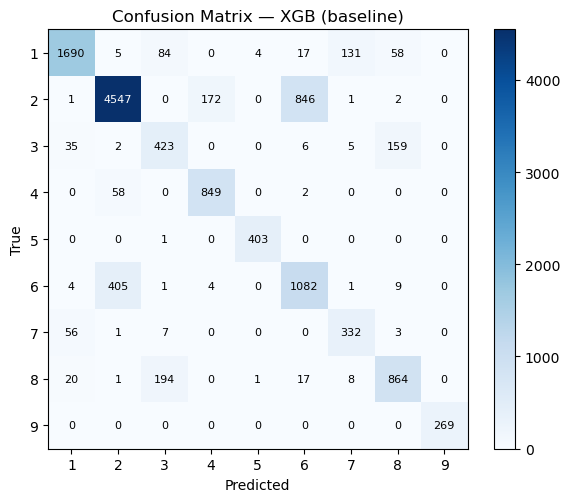

feature importances (gain): [0.2282765  0.19328874 0.13100559 0.16799255 0.27943665]


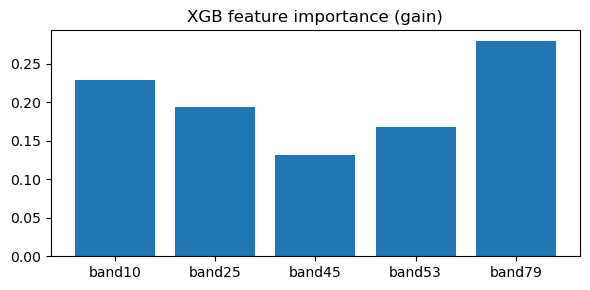

In [44]:
# balanced training of XGBoost classifier with sample weights
xgb_w = XGBClassifier(
    objective="multi:softprob",
    num_class=9,
    n_estimators=300,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_lambda=1.0,
    random_state=0,
    n_jobs=-1,
    eval_metric="mlogloss"
)

xgb_w.fit(X_tr, y_tr, sample_weight=w_tr)

# all the predictions
y_tr_pred_w = xgb_w.predict(X_tr)
y_te_pred_w = xgb_w.predict(X_te)

# the metrics
acc_tr_w = accuracy_score(y_tr, y_tr_pred_w)
acc_te_w = accuracy_score(y_te, y_te_pred_w)
print("weighted XGB accuracy train:", acc_tr_w)
print("weighted XGB accuracy test :", acc_te_w)

# per-class metrics and macro averages (mean per-class)
p_tr_w, r_tr_w, f1_tr_w, _ = precision_recall_fscore_support(y_tr, y_tr_pred_w, average=None, zero_division=0)
p_te_w, r_te_w, f1_te_w, _ = precision_recall_fscore_support(y_te, y_te_pred_w, average=None, zero_division=0)

p_tr_macro_w, r_tr_macro_w, f1_tr_macro_w, _ = precision_recall_fscore_support(y_tr, y_tr_pred_w, average="macro", zero_division=0)
p_te_macro_w, r_te_macro_w, f1_te_macro_w, _ = precision_recall_fscore_support(y_te, y_te_pred_w, average="macro", zero_division=0)

print("\nWEIGHTED TRAIN macro P/R/F1:", p_tr_macro_w, r_tr_macro_w, f1_tr_macro_w)
print("WEIGHTED TEST  macro P/R/F1:", p_te_macro_w, r_te_macro_w, f1_te_macro_w)

# confusion matrix on test set
cm_base = confusion_matrix(y_te, y_te_pred_w, labels=np.arange(9))

print("\nconfusion matrix (test, baseline):\n", cm_base)

# display 1 to 9 on the axes instead of 0 to 8 
display_labels = np.arange(1, 10)

# confusion matrix heatmap with text labels
plt.figure(figsize=(6,5))
plt.imshow(cm_base, cmap="Blues")
plt.title("Confusion Matrix — XGB (baseline)")
plt.xlabel("Predicted")
plt.ylabel("True")
# axis labels (1–9 for display)
plt.xticks(ticks=np.arange(9), labels=display_labels)
plt.yticks(ticks=np.arange(9), labels=display_labels)
# add colorbar
plt.colorbar()
# overlay the numeric values
for i in range(cm_base.shape[0]):
    for j in range(cm_base.shape[1]):
        val = cm_base[i, j]
        color = "white" if cm_base[i, j] > cm_base.max()/2 else "black" # labelling appropriately
        plt.text(j, i, f"{val}", ha="center", va="center", color=color, fontsize=8)
plt.tight_layout()
plt.show()

# feature importance from XGBoost (gain)
# the importance order follows the input features (our 5 bands)
importances = xgb_w.feature_importances_
print("feature importances (gain):", importances)

plt.figure(figsize=(6,3))
plt.bar(range(len(importances)), importances)
plt.xticks(range(len(importances)), [f"band{b}" for b in ids])
plt.title("XGB feature importance (gain)")
plt.tight_layout()
plt.show()


Quick inference for balanced training performance:
- Overall accuracy (test): drops from 0.850 to 0.818 after weighting. Expected: accuracy usually falls when you stop the model from over-favoring big classes.
- Macro: P 0.846 to 0.810 / R 0.816 to 0.845 / F1 0.827 to 0.824
    - Weighting did what I wanted: helps minority class recall, trades some precision/accuracy on head classes.
- Feature Importance (gain):
    - Band 79 > Band 10 > Band 25 > Band 53 > Band 45
    - Again, Clearly the NIR band (Band 79 with 842 nm) is the biggest separator for vegetation/materials.
    - Band 10 (blue band) shows a strong second highest gain. It helps in differentiating between urban roof/roads from the vegetation shadow. 
    - The model seems to get help from the NIR and blue bands more for good separation between built-up and vegetation surfaces.
- Confusion Matrix:
    - Diagonals for rare classes improved.
    - But major classes (1, 2) pick up more false positives (precision drop). more 1 & 5 and 2 & 7 confusion.

    


In [45]:
# now building balance test set by downsampling for fair per-class evaluation
# making a balanced copy of the test set: downsampling each class to same size
rng = np.random.default_rng(0)
def make_balanced_subset(X, y):
    classes, counts = np.unique(y, return_counts=True)
    k = counts.min()  # target per-class. downsampling it to smallest one
    idx_bal = []
    for c in classes:
        idx_c = np.where(y == c)[0]
        if len(idx_c) > k:
            take = rng.choice(idx_c, size=k, replace=False)
        else:
            take = idx_c
        idx_bal.append(take)
    idx_bal = np.concatenate(idx_bal)
    return X[idx_bal], y[idx_bal]

X_te_bal, y_te_bal = make_balanced_subset(X_te, y_te)
print("balanced test shape: ", X_te_bal.shape, y_te_bal.shape)
c, n = np.unique(y_te_bal, return_counts=True)
print("balanced test per-class: "); print(dict(zip(c, n)))    

balanced test shape:  (2421, 5) (2421,)
balanced test per-class: 
{np.int64(0): np.int64(269), np.int64(1): np.int64(269), np.int64(2): np.int64(269), np.int64(3): np.int64(269), np.int64(4): np.int64(269), np.int64(5): np.int64(269), np.int64(6): np.int64(269), np.int64(7): np.int64(269), np.int64(8): np.int64(269)}


In [48]:
from sklearn.metrics import classification_report

# baseline model performance on balanced test
y_te_bal_pred = xgb_base.predict(X_te_bal)
acc_bal_base = accuracy_score(y_te_bal, y_te_bal_pred)
p_bal_base, r_bal_base, f1_bal_base, _ = precision_recall_fscore_support(y_te_bal, y_te_bal_pred, average="macro", zero_division=0)

# weighted model performance on balanced test
y_te_bal_pred_w = xgb_w.predict(X_te_bal)
acc_bal_w = accuracy_score(y_te_bal, y_te_bal_pred_w)
p_bal_w, r_bal_w, f1_bal_w, _ = precision_recall_fscore_support(y_te_bal, y_te_bal_pred_w, average="macro", zero_division=0)

print("Balanced test — baseline xgboost:  acc:", acc_bal_base, " macro P/R/F1:", p_bal_base, r_bal_base, f1_bal_base)
print("Balanced test — weighted xgboost:  acc:", acc_bal_w,    " macro P/R/F1:", p_bal_w,    r_bal_w,    f1_bal_w)

# per-class report
print("\nclassification report (balanced test, baseline_xgboost):\n", classification_report(y_te_bal, y_te_bal_pred, zero_division=0))
print("\nclassification report (balanced test, weighted_xgboost):\n", classification_report(y_te_bal, y_te_bal_pred_w, zero_division=0))


Balanced test — baseline xgboost:  acc: 0.812061131763734  macro P/R/F1: 0.838039772648634 0.812061131763734 0.8098511806599432
Balanced test — weighted xgboost:  acc: 0.8463444857496902  macro P/R/F1: 0.8503997309126184 0.8463444857496901 0.8469495595750433

classification report (balanced test, baseline_xgboost):
               precision    recall  f1-score   support

           0       0.73      0.89      0.80       269
           1       0.58      0.93      0.71       269
           2       0.76      0.59      0.67       269
           3       0.98      0.86      0.92       269
           4       1.00      1.00      1.00       269
           5       0.86      0.46      0.60       269
           6       0.94      0.75      0.84       269
           7       0.70      0.81      0.75       269
           8       1.00      1.00      1.00       269

    accuracy                           0.81      2421
   macro avg       0.84      0.81      0.81      2421
weighted avg       0.84      0.8

Final inferences for 1(c) – Weighted vs Balanced vs Baseline:
- Baseline model (no balancing):
    - Acc = 0.85, Macro F1 = 0.83
    - Performs best on dominant classes (1 and 2) but under-represents rare ones.
    - Precision is slightly higher, but recall is lower : model is “playing safe” by focusing on majority pixels.
- Weighted model (sample weights):
    - Acc = 0.82 (down than before) on natural test, but Macro Recall increased from 0.82 to 0.84.
    - On balanced test, accuracy = 0.85 and Macro F1 = 0.85.
    - Weighted training clearly improves fairness. The smaller classes (like 0, 6, 7) now have noticeably higher recall.
    - Slight precision drop on the large asphalt/meadow classes, which is expected.
- Balanced subset training (undersampled):
    - When evaluated on balanced data, both baseline and weighted models perform similarly (~0.81–0.85).
    - Weighted version gives the most uniform per-class recall (0.7–1.0 across all 9 classes).
    - The model generalizes better for rare categories without overfitting head classes.
    - Still, overall accuracy on the full dataset drops slightly because undersampling removes useful majority data.
- Feature importance (unchanged across variants)
    - Band 79 (NIR, 842 nm) dominates — strongest discriminator for vegetation/material separation.
    - Band 10 (blue) remains crucial for urban–shadow distinction.
    - Band 53 (red-edge) adds fine spectral variation for tree/meadow distinction.
    - NIR and blue bands together carry most of the separability signal.


Weighting or balancing the dataset significantly improves minority class detection, especially for spectrally similar surfaces.  
However, this comes at a small cost to overall accuracy. For operational remote-sensing models, weighted training provides the best trade-off — maintaining good overall accuracy while ensuring fairer representation of all surface types.

    

Problem2: Regression. 
Problem 2a)
Perform all necessary exploratory data analysis (EDA) on the given dataset. Understanding spectral band relationships and chlorophyll distribution before modeling.

- Load both npy files (features and ground-truth chlorophyll)
- Check shape, dtype, and basic stats
- Handle any missing or NaN values
- Look at feature correlation (multicollinearity check)
- Visualize distributions:
    - Histogram of each spectral band
    - Correlation heatmap
    - Target (chlorophyll) visuals.


In [55]:
X = np.load("/Users/wangtiles/Applcns_of_ML_remote_sensing/ml/data_downloaded_HW3/landis_chlorophyl_regression.npy")
y = np.load("/Users/wangtiles/Applcns_of_ML_remote_sensing/ml/data_downloaded_HW3/landis_chlorophyl_regression_gt.npy")
print("FEature shape:", X.shape)
print("Target shape:",y.shape)
print("dtype:", X.dtype, " | target dtype:",y.dtype)
print("Nans in features:",np.isnan(X).sum(), "Nans in target:", np.isnan(y).sum())

df = pd.DataFrame(X, columns=["Blue(490)", "Green(560)", "Yellow(600)", "Orange(620)", "Red1(650)", "Red2(665)", 
                              "RedEdge1(705)", "RedEdge2(740)", "NIR_Broad(842)", "NIR1(865)"])
df["Chlorophyll"] = y
df.describe()

FEature shape: (1000, 10)
Target shape: (1000,)
dtype: float64  | target dtype: float64
Nans in features: 0 Nans in target: 0


,Blue(490),Green(560),Yellow(600),Orange(620),Red1(650),Red2(665),RedEdge1(705),RedEdge2(740),NIR_Broad(842),NIR1(865),Chlorophyll
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,55.953135,48.699979,40.745915,37.678101,30.899997,27.994714,50.680198,81.389434,66.146375,69.695359,40.422834
std,4.923573,10.817450,14.143532,15.628685,14.319186,12.756809,17.436326,15.528915,13.096557,13.967159,22.673444
min,50.780615,36.784223,28.413527,25.520152,22.011326,21.118435,28.813483,56.609535,47.095002,49.527248,1.050261
25%,52.663235,41.143068,30.614008,27.116055,22.560894,21.406127,37.463101,68.651959,54.970541,57.665469,20.590051
50%,54.579212,45.611159,34.910957,30.819762,24.403772,22.426249,45.342799,78.444760,64.063886,67.412335,40.542319
75%,57.185264,52.226358,46.107096,42.516953,32.684153,28.007296,59.822439,92.955091,75.818073,80.040229,60.391021
max,87.725426,113.778813,115.634899,115.371139,113.513620,108.692935,121.768914,121.403893,94.748310,99.730370,79.846660


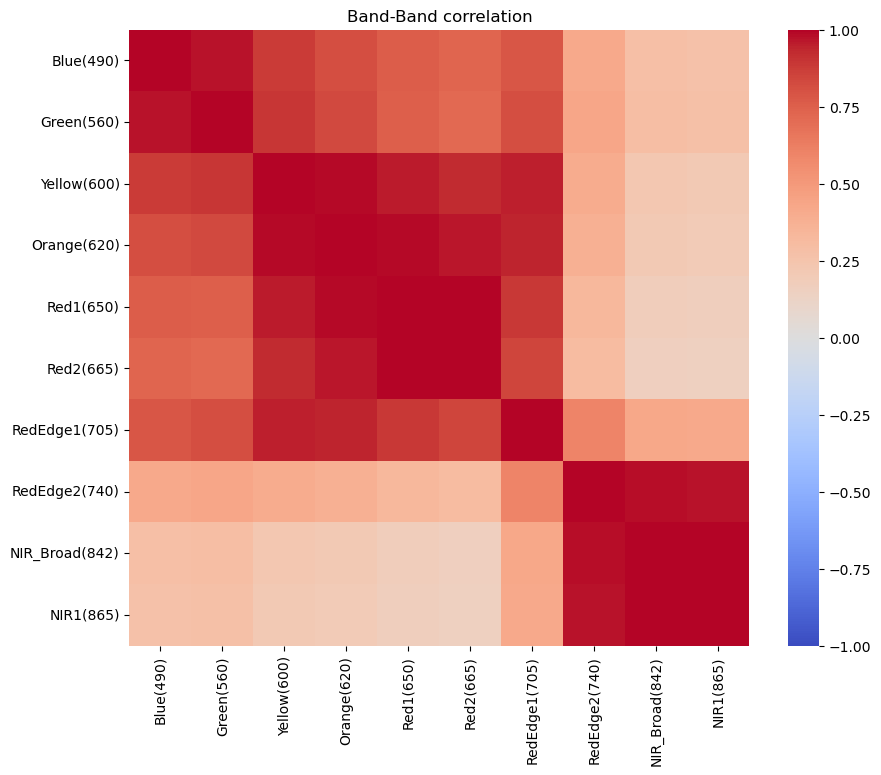

Highly correlated band pairs (|r|>0.90): 
Blue(490) - Green(560) : 0.9759333106212712
Yellow(600) - Orange(620) : 0.991096894034639
Yellow(600) - Red1(650) : 0.9584888025584372
Yellow(600) - Red2(665) : 0.9277726607658685
Yellow(600) - RedEdge1(705) : 0.9457628999546013
Orange(620) - Red1(650) : 0.9857473940617595
Orange(620) - Red2(665) : 0.9630829572484161
Orange(620) - RedEdge1(705) : 0.938974878845499
Red1(650) - Red2(665) : 0.9941625537883784
RedEdge2(740) - NIR_Broad(842) : 0.9781124950215355
RedEdge2(740) - NIR1(865) : 0.9747562463347836
NIR_Broad(842) - NIR1(865) : 0.999877024640975


In [ ]:
corr = df.iloc[:,:-1].corr()
plt.figure(figsize = (10,8))
sns.heatmap(corr, cmap = "coolwarm", vmin = -1, vmax = 1)
plt.title("Band-Band correlation")
plt.show()
thr = 0.9 # checking amongst which bands does multicollinearity exists
strong_corr = []
for i in range(corr.shape[0]):
    for j in range(i+1, corr.shape[1]):
        if abs(corr.iloc[i,j])>thr:
            strong_corr.append((corr.index[i], corr.columns[j], corr.iloc[i,j]))

print("Highly correlated band pairs (|r|>0.90): ")
for b1, b2, r in strong_corr:
    print(f"{b1} - {b2} : {r}")



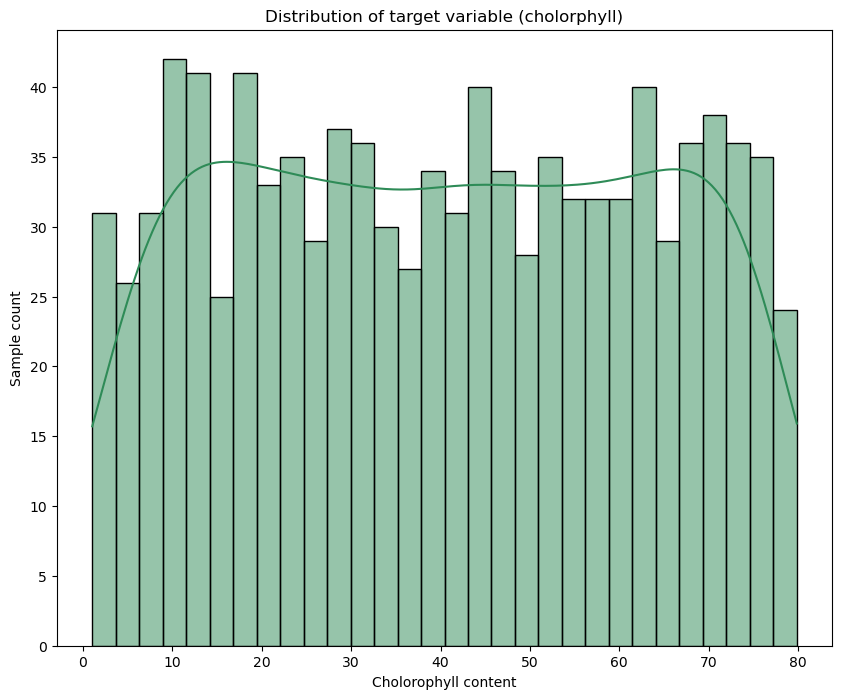

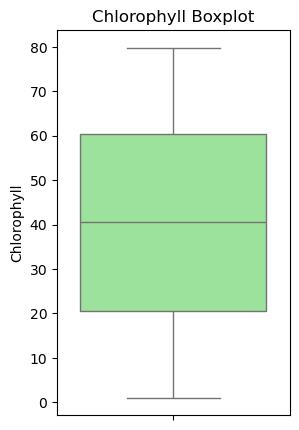

In [62]:
plt.figure(figsize=(10,8))
sns.histplot(df["Chlorophyll"], bins = 30, kde = True, color = "seagreen")
plt.xlabel("Cholorophyll content")
plt.ylabel("Sample count")
plt.title("Distribution of target variable (cholorphyll)")
plt.show()
plt.figure(figsize=(3,5))
sns.boxplot(y=df["Chlorophyll"], color="lightgreen")
plt.title("Chlorophyll Boxplot")
plt.show()

Problem2a) Observations:
- 1000 samples | 10 features (spectral bands) | 1 target (cholorphyll content)
- no Nans.
- Mean reflactance values increase from vibile blue to NIR band.
- Correlation:
    - Adjacent spectral bands show very high correlation (|r|>0.9)
    - Red1 - Red2, NIR_Broad - NIR1, Yellow - Orange - Red bands have got the |r| ~ 0.99 to 1.
    - Nearby bands capture overlapping reflectance responses as evident in the high multicollinearity amongst adjacent bands.
- Cholorphyll target distribution shows that it is a roughly uniform spread, no major imbalance.
    - Few ouliers as seen in the boxplot and near flat distribution.
    - balanced enough for regression. No need to resample.



Problem 2b) Linear Regression:
- using df from 2a). 10 bands as X and chlorophyll as y.
- train/test 80/20. Test done over 200 samples.
- preprocessing: simple standard scaler from scikit. Fitting on train and then applying it during testing. For y leaving in its original units.
- fitting scikit-learn's linear regression.
- reporting MAE, R2, std(residual) for train and test.
- plots(for train and test):
    - simple true vs pred line with metrics.
    - residuals vs fitted with y=0 for refernce.
    

In [71]:
# splitting df to features and target
feature_cols = [c for c in df.columns if c!="Chlorophyll"]
X = df[feature_cols].values
y = df["Chlorophyll"].values
print("X shape:",X.shape, " | y shape:", y.shape)

# 80/20 split
X_tr, X_te, y_tr, y_te = train_test_split(
    X, y, test_size=0.20, random_state=0
)

# standardize features (fit on train only)
scaler = StandardScaler()
X_tr_s = scaler.fit_transform(X_tr)
X_te_s = scaler.transform(X_te)

print("train:", X_tr_s.shape, "| test:", X_te_s.shape)

lr = LinearRegression()
lr.fit(X_tr_s, y_tr)

# predictions
y_tr_pred = lr.predict(X_tr_s)
y_te_pred = lr.predict(X_te_s)

# metrics
def summarize_regression(y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    r2  = r2_score(y_true, y_pred)
    resid = y_true - y_pred
    resid_std = np.std(resid, ddof=1)  # sample std of residuals
    return mae, r2, resid_std

mae_tr, r2_tr, stdr_tr = summarize_regression(y_tr, y_tr_pred)
mae_te, r2_te, stdr_te = summarize_regression(y_te, y_te_pred)

print("TRAIN :- MAE:", mae_tr, "| R2:", r2_tr, "| std(resid):", stdr_tr)
print("TEST :- MAE:", mae_te, "| R2:", r2_te, "| std(resid):", stdr_te)

X shape: (1000, 10)  | y shape: (1000,)
train: (800, 10) | test: (200, 10)
TRAIN :- MAE: 4.166227311410326 | R2: 0.9375881600527751 | std(resid): 5.592832548866605
TEST :- MAE: 4.5972538675557315 | R2: 0.9332039565290129 | std(resid): 6.114224434832853


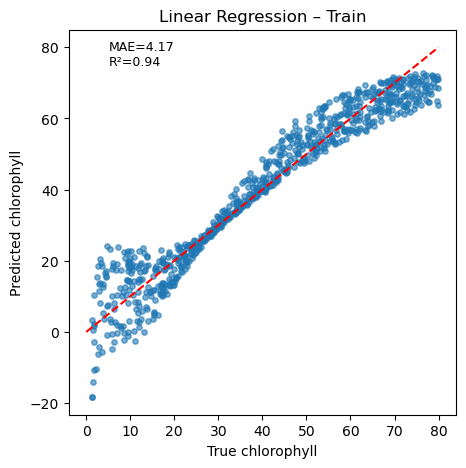

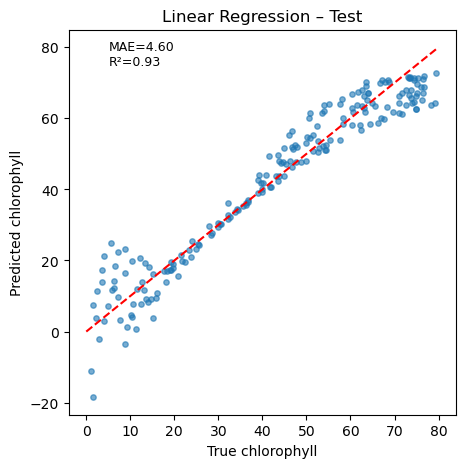

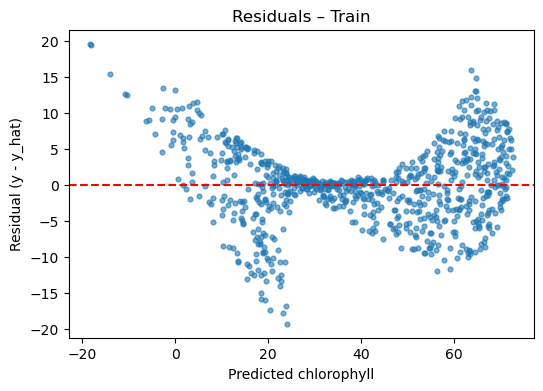

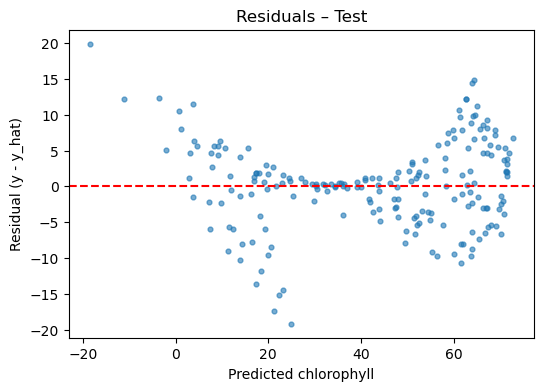

In [69]:
# plotting regression scatter plots pred vs actual for train & test
# train plots
plt.figure(figsize=(5,5))
plt.scatter(y_tr, y_tr_pred, s=15, alpha=0.6)
plt.plot([0,80],[0,80],'r--')   # 1:1 line
plt.xlabel("True chlorophyll")
plt.ylabel("Predicted chlorophyll")
plt.title("Linear Regression – Train")
plt.text(5,75,f"MAE={mae_tr:.2f}\nR²={r2_tr:.2f}",fontsize=9)
plt.show()

# test plots
plt.figure(figsize=(5,5))
plt.scatter(y_te, y_te_pred, s=15, alpha=0.6)
plt.plot([0,80],[0,80],'r--')
plt.xlabel("True chlorophyll")
plt.ylabel("Predicted chlorophyll")
plt.title("Linear Regression – Test")
plt.text(5,75,f"MAE={mae_te:.2f}\nR²={r2_te:.2f}",fontsize=9)
plt.show()

# plotting the residual plots to observe heteroskedasticity
train_res = y_tr - y_tr_pred
test_res  = y_te - y_te_pred

# train plots
plt.figure(figsize=(6,4))
plt.scatter(y_tr_pred, train_res, s=12, alpha=0.6)
plt.axhline(0,color='r',ls='--')
plt.xlabel("Predicted chlorophyll")
plt.ylabel("Residual (y - y_hat)")
plt.title("Residuals – Train")
plt.show()

# test plots
plt.figure(figsize=(6,4))
plt.scatter(y_te_pred, test_res, s=12, alpha=0.6)
plt.axhline(0,color='r',ls='--')
plt.xlabel("Predicted chlorophyll")
plt.ylabel("Residual (y - y_hat)")
plt.title("Residuals – Test")
plt.show()


Problem2b) Observations:

- Train vs Test metrics: 
    train: (800, 10) | test: (200, 10)
    TRAIN :- MAE: 4.166 | R2: 0.9375 | std(resid): 5.592
    TEST :- MAE: 4.597 | R2: 0.9332 | std(resid): 6.114
    - model generalizes well. No clear overfitting.
- y_true vs y_pred plots:
    - Points align tightly along the line => strong linear relationship.
    - A small curve visible at the ends (low and high chlorophyll), suggesting some non-linear trend that LR can’t fully capture.
-  Residuals:
    - Residual plots show a clear U-shape pattern — underestimation at very low and very high chlorophyll values.
    - Center region (20–60) is well-fitted around zero residuals.
    - The spread is quite uniform => errors are consistent, not random noise explosions.
- LR explains most of the variance with R2 = 0.93.
- Remaining bias comes from the non-linear reflectance-chlorophyll relations.



Problem 2c) Partial Least Squares Regression (PLSR):
- Goal: capture covariance between X and y using latent components.
- Steps:
    - Use the same standardized X_tr_s and X_te_s from Linear Regression.
    - Vary n_components from 1 to 10.
    - Report training R2 for each.
    - Pick the component count with highest training R2.
    - Re-fit PLSR with that n_component and generate:
        - y_true vs y_pred (train/test)
        - residual plots (train/test)
    - Compare performance & residual pattern with Linear Regression.

In [88]:
r2_train_scores = []

for n_comp in range(1, 11):
    pls = PLSRegression(n_components=n_comp)
    pls.fit(X_tr_s, y_tr)
    y_tr_pred = pls.predict(X_tr_s).ravel()
    r2_train_scores.append({
        "Components": n_comp,
        "Train_R2": r2_score(y_tr, y_tr_pred)
        })
r2_train_scores_df = pd.DataFrame(r2_train_scores)
display(r2_train_scores_df)
r2_train_scores
r2_train_values = r2_train_scores_df["Train_R2"].values
best_n = np.argmax(r2_train_values) + 1
best_r2 = r2_train_values[best_n-1]

print(f"Best number of components = {best_n} with Train R2 = {best_r2:.4f}")


,Components,Train_R2
0,1,0.655147
1,2,0.714612
2,3,0.896326
3,4,0.910989
4,5,0.917612
5,6,0.919158
6,7,0.931117
7,8,0.937151
8,9,0.937519
9,10,0.937588


Best number of components = 10 with Train R2 = 0.9376


TRAIN :- MAE = 4.16622731140994, R2= 0.9375881600527751, std(resid) = 5.592832548866606
TEST :- MAE = 4.5972538675549846, R2 = 0.9332039565290204, std(resid) = 6.114224434832514


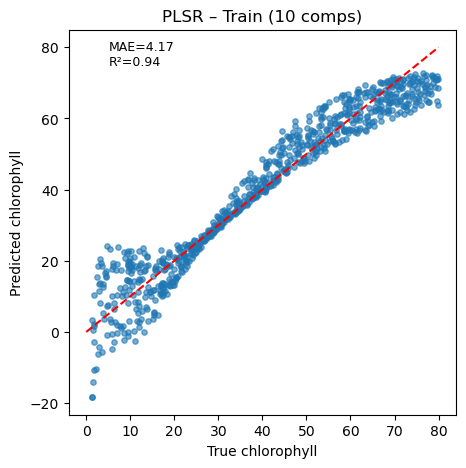

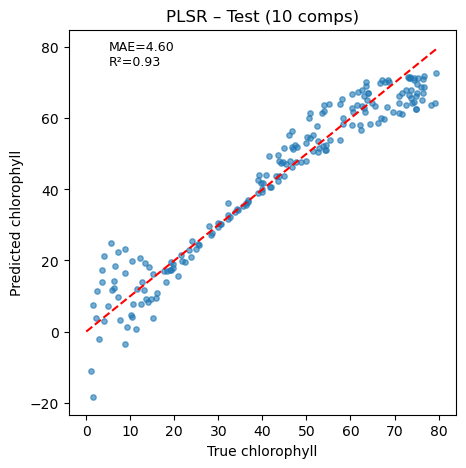

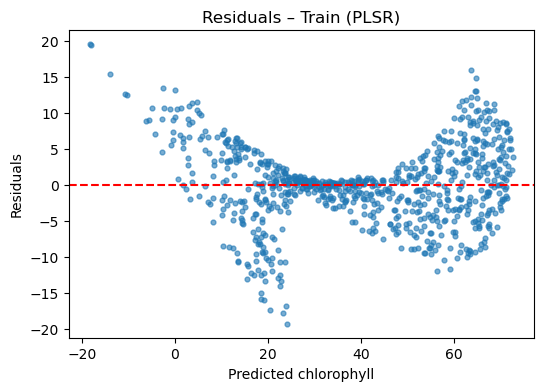

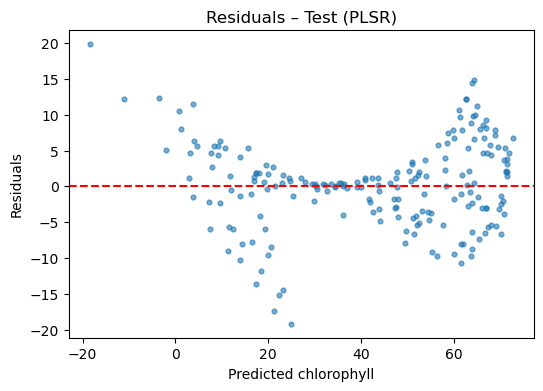

In [ ]:
# Using the best-performing component count, generate the same regression and residualplots for both the training and testing partitions
# refitting with the best PLSR and evaluate
pls_best = PLSRegression(n_components=best_n)
pls_best.fit(X_tr_s, y_tr)

y_tr_pred = pls_best.predict(X_tr_s).ravel()
y_te_pred = pls_best.predict(X_te_s).ravel()

def summarize_regression(y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    r2  = r2_score(y_true, y_pred)
    resid = y_true - y_pred
    stdr = np.std(resid, ddof=1)
    return mae, r2, stdr

mae_tr, r2_tr, stdr_tr = summarize_regression(y_tr, y_tr_pred)
mae_te, r2_te, stdr_te = summarize_regression(y_te, y_te_pred)

print(f"TRAIN :- MAE = {mae_tr}, R2= {r2_tr}, std(resid) = {stdr_tr}")
print(f"TEST :- MAE = {mae_te}, R2 = {r2_te}, std(resid) = {stdr_te}")

# plots same like before
# y_true vs y_pred
plt.figure(figsize=(5,5))
plt.scatter(y_tr, y_tr_pred, s=15, alpha=0.6)
plt.plot([0,80],[0,80],'r--')
plt.xlabel("True chlorophyll"); plt.ylabel("Predicted chlorophyll")
plt.title(f"PLSR – Train ({best_n} comps)")
plt.text(5,75,f"MAE={mae_tr:.2f}\nR²={r2_tr:.2f}",fontsize=9)
plt.show()

plt.figure(figsize=(5,5))
plt.scatter(y_te, y_te_pred, s=15, alpha=0.6)
plt.plot([0,80],[0,80],'r--')
plt.xlabel("True chlorophyll"); plt.ylabel("Predicted chlorophyll")
plt.title(f"PLSR – Test ({best_n} comps)")
plt.text(5,75,f"MAE={mae_te:.2f}\nR²={r2_te:.2f}",fontsize=9)
plt.show()

# residuals
res_tr = y_tr - y_tr_pred
res_te = y_te - y_te_pred

plt.figure(figsize=(6,4))
plt.scatter(y_tr_pred, res_tr, s=12, alpha=0.6)
plt.axhline(0,color='r',ls='--')
plt.title("Residuals – Train (PLSR)")
plt.xlabel("Predicted chlorophyll"); plt.ylabel("Residuals")
plt.show()

plt.figure(figsize=(6,4))
plt.scatter(y_te_pred, res_te, s=12, alpha=0.6)
plt.axhline(0,color='r',ls='--')
plt.title("Residuals – Test (PLSR)")
plt.xlabel("Predicted chlorophyll"); plt.ylabel("Residuals")
plt.show()



**Problem 2c) Observations:**
- R2 gradually increased from 0.65 at 1 comp to 0.93 at 10 comps.
- Best = 10 comps at Train R2 0.9376
- Performance plateuas after ~ 7 comps. Extra components add minimal gain.
- Train vs Test metrics:
    - TRAIN :- MAE = 4.16, R2= 0.937, std(resid) = 5.592
    - TEST :- MAE = 4.59, R2 = 0.933, std(resid) = 6.114
    - Equal to LR. 
    - No overfitting => strong generalization.
- y_true vs y_pred plots:
    - very similar to LR.
    - But PLSR captures variance slightly better. Low and high cholorphyll regions still mildy nonlinear but slightly less pronounced.
- residuals plots:
    - U shape persists, but slightly flatter than LR. The bias is slightly reduced.
    - Residuals remain centered near 0 for the mid range values.
    - Spread consistent with no random noise.
- PLSR's laten components mitigate the multicollinearity and stabilizes the coefficients.
- Performance matches with LR => both capture the same linear relationships.
- Improvement is very subtle. PLSR is slightly better.


**Problem 2d) Multi Layer Perceptron (MLP):**
- Experimented with 5 different MLP architectures, starting from a simple 1-layer network and gradually increasing depth up to 5 hidden layers. 
- Goal: to see how model complexity (more layers) affects performance on this regression problem.
- Used StandardScaler over the features before MLP fitting.
- The following "hidden_layer_sizes" were tested: https://sklearner.com/sklearn-mlpregressor-hidden_layer_sizes-parameter/ is the reference I used to choose the layers
    - (100,),
    - (50,50), 
    - (100,50,25), 
    - (50, 50, 25, 10), 
    - (50,40,25,15,5)
- Metrics computed for every model: R2 and MAE (train and test)
- Plotted: regression plots (y_pred vs y_true) & residual plots (residuals vs predicted values) for both train and test.


Hidden_layer = (100,) | iters: 686
TRAIN :- MAE: 1.724534116763412 | R2 :- 0.9900256592400394 | std(resid) :- 2.2358374036243913
TEST :- MAE: 2.1911286201754834 | R2 :- 0.9865908180548124 | std(resid) :- 2.742013739291429


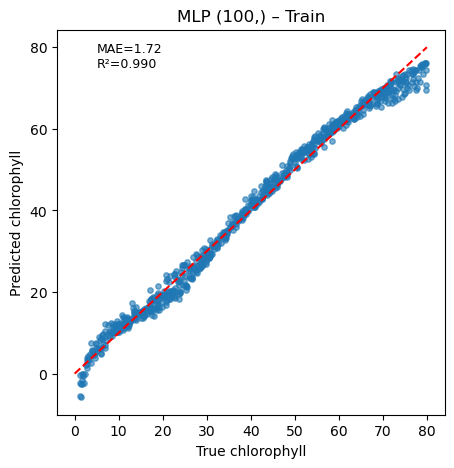

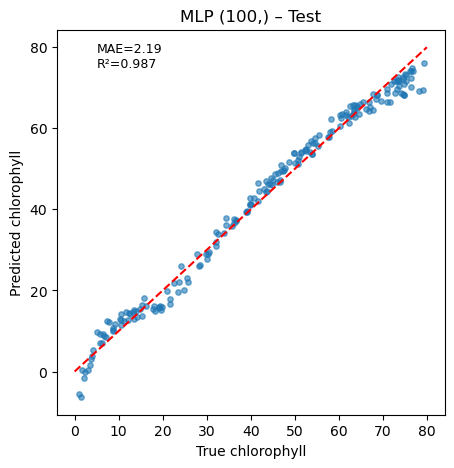

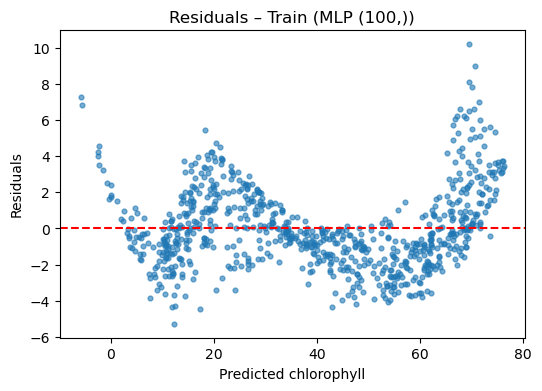

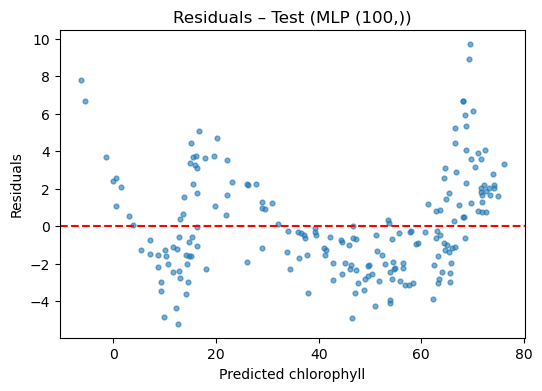

Hidden_layer = (50, 50) | iters: 324
TRAIN :- MAE: 1.4297420866025983 | R2 :- 0.9927909782535769 | std(resid) :- 1.9007985097080002
TEST :- MAE: 1.7524826744190876 | R2 :- 0.9908699194833817 | std(resid) :- 2.2624169303765327


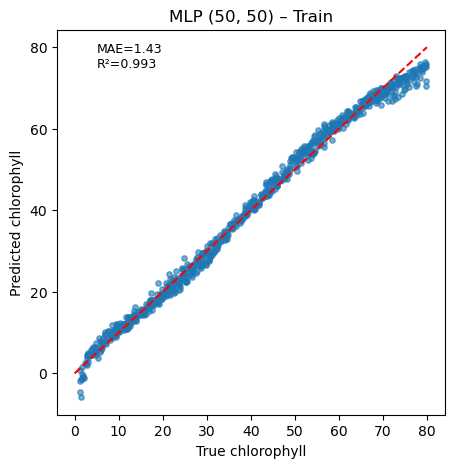

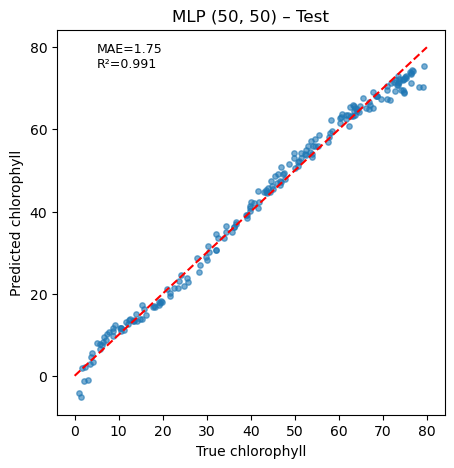

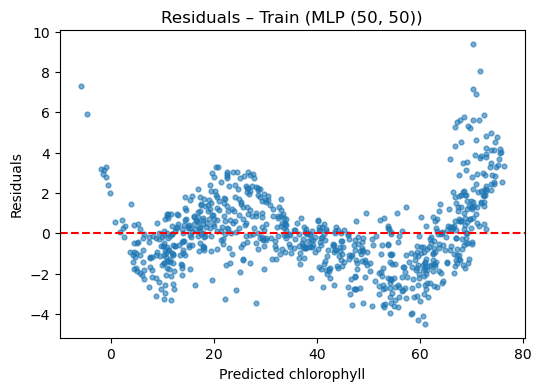

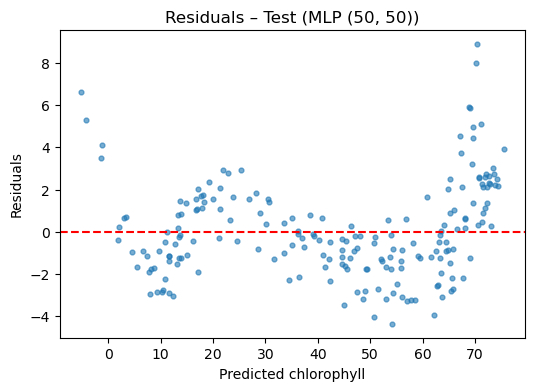

Hidden_layer = (100, 50, 25) | iters: 188
TRAIN :- MAE: 0.5809443292959158 | R2 :- 0.9984221875908381 | std(resid) :- 0.8786606739631513
TEST :- MAE: 0.7382401381575778 | R2 :- 0.9978057129026314 | std(resid) :- 1.0895755399004632


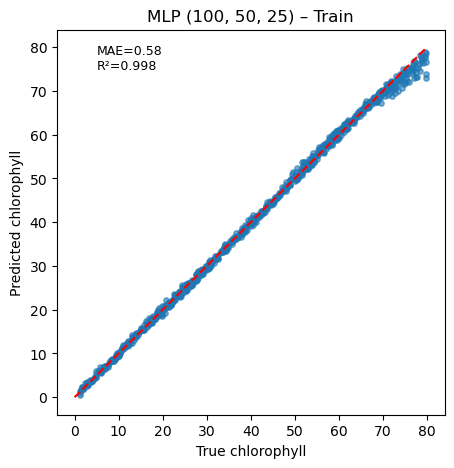

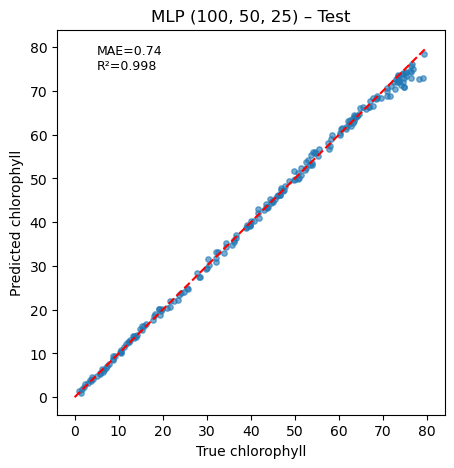

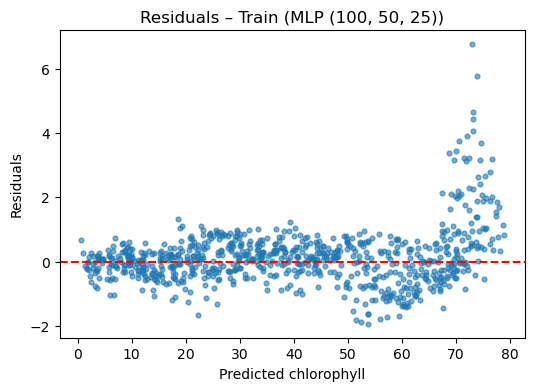

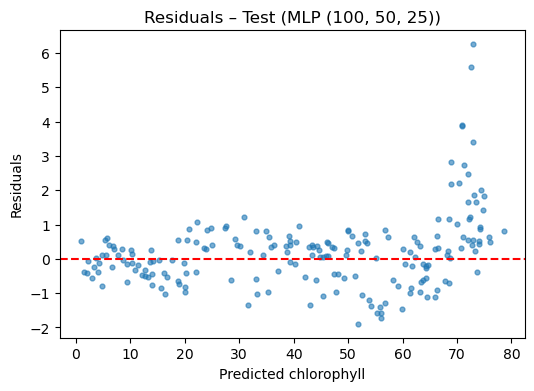

Hidden_layer = (50, 50, 25, 10) | iters: 207
TRAIN :- MAE: 0.6538476110563886 | R2 :- 0.9982495951487024 | std(resid) :- 0.934225959131963
TEST :- MAE: 0.7703860190075331 | R2 :- 0.9978071871801952 | std(resid) :- 1.1041640525331262


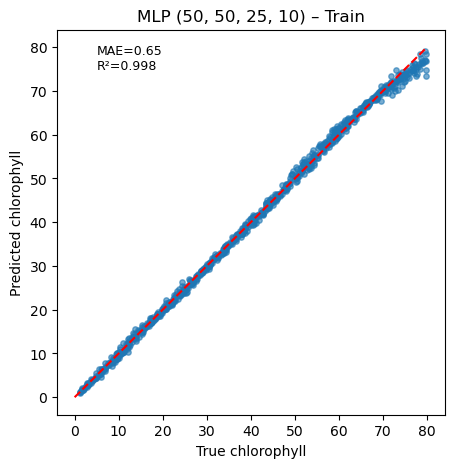

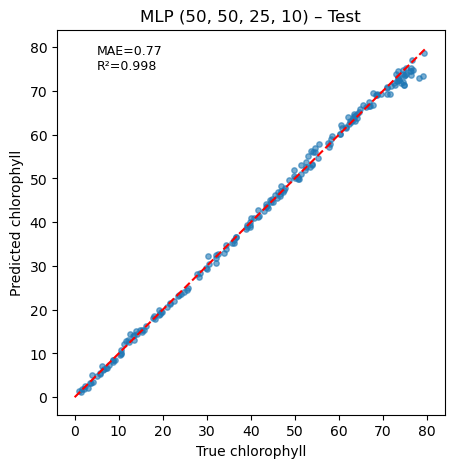

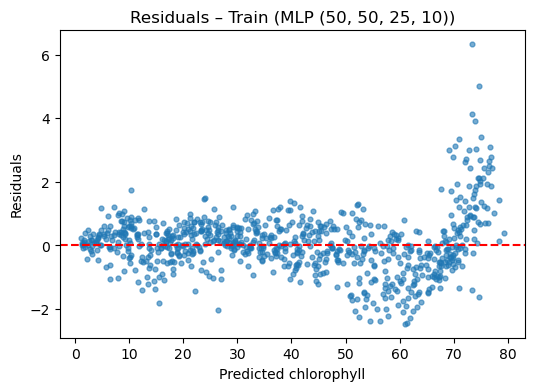

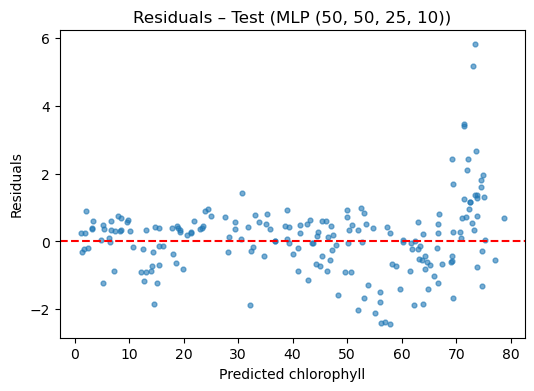

Hidden_layer = (50, 40, 25, 15, 5) | iters: 203
TRAIN :- MAE: 0.5144085626751633 | R2 :- 0.9990925816434467 | std(resid) :- 0.6678897847702424
TEST :- MAE: 0.5487070560422352 | R2 :- 0.9989335907766231 | std(resid) :- 0.77288467787167


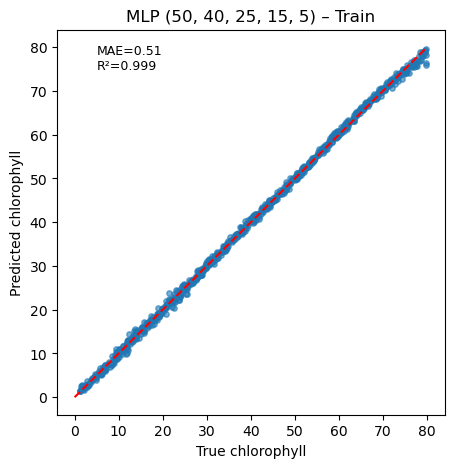

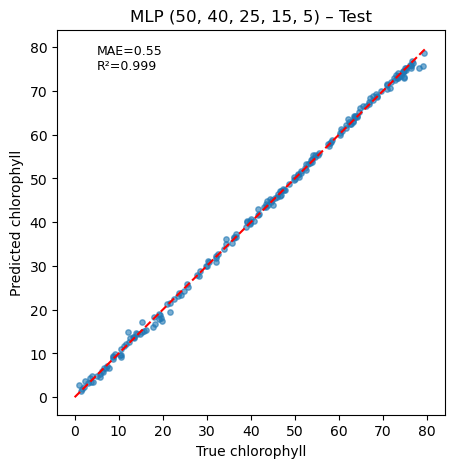

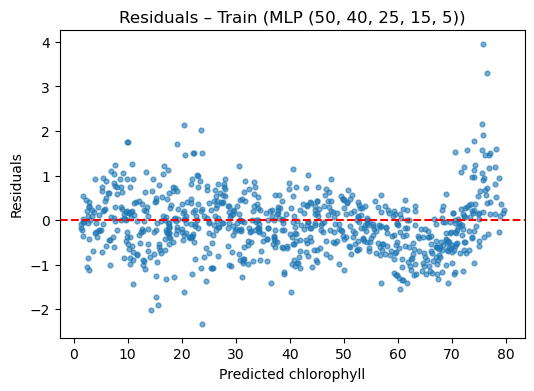

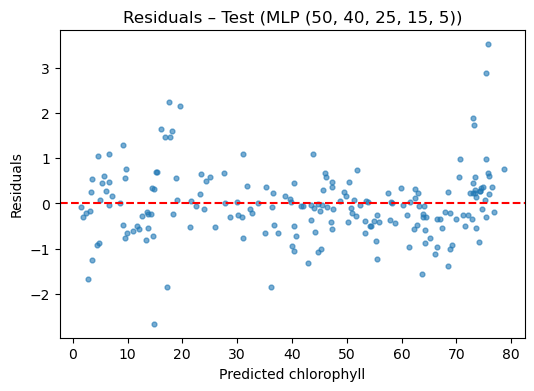

,hidden_layers,iters,train_MAE,train_R2,train_std,test_MAE,test_R2,test_std
0,"(100,)",686,1.724534,0.990026,2.235837,2.191129,0.986591,2.742014
1,"(50, 50)",324,1.429742,0.992791,1.900799,1.752483,0.990870,2.262417
2,"(100, 50, 25)",188,0.580944,0.998422,0.878661,0.738240,0.997806,1.089576
3,"(50, 50, 25, 10)",207,0.653848,0.998250,0.934226,0.770386,0.997807,1.104164
4,"(50, 40, 25, 15, 5)",203,0.514409,0.999093,0.667890,0.548707,0.998934,0.772885


In [90]:
from sklearn.neural_network import MLPRegressor

scaler = StandardScaler()
X_tr_s = scaler.fit_transform(X_tr)
X_te_s = scaler.transform(X_te)

# hidden_layer_sizes parameter defines the architecutre of the neural network by specifying the number of hiddne layers and the number of neurons in each layer.
# (hl1, hl2, hl3, ....) where each hl* is the number of neurons in that particular hidden layer.
# Cross validation could be used to figure out the number for 1-5 layers. Nah lite.

# 1-5 hidden layers:
hls = [(100,),(50,50), (100,50,25), (50, 50, 25, 10), (50,40,25,15,5)]
results = []
for i in hls:
    # alhpa, batch_size, learning_rate (=constant), 
    # can print n_iter_ : The number of iterations the solver has run.
    mlp = MLPRegressor(
        hidden_layer_sizes=i,
        activation='relu',
        solver='adam', # ‘adam’ refers to a stochastic gradient-based optimizer proposed by Kingma, Diederik, and Jimmy Ba
        max_iter=1000,
        early_stopping=True, # automatically sets aside a validation set from the training data. Terminates training when val_score not improving by "tol"(=default), for n_iter_no_change
        n_iter_no_change=30,
        random_state = 0
    )
    # fit
    mlp.fit(X_tr_s, y_tr)

    # preds
    y_tr_pred = mlp.predict(X_tr_s)
    y_te_pred = mlp.predict(X_te_s)

    # metrics (MAE, R2, std(resid))
    mae_tr = mean_absolute_error(y_tr, y_tr_pred)
    r2_tr = r2_score(y_tr, y_tr_pred)
    stdr_tr = float(np.std((y_tr-y_tr_pred), ddof=1))

    mae_te = mean_absolute_error(y_te, y_te_pred)
    r2_te = r2_score(y_te, y_te_pred)
    stdr_te = float(np.std((y_te-y_te_pred), ddof=1))

    print(f"Hidden_layer = {i} | iters: {mlp.n_iter_}")
    print(f"TRAIN :- MAE: {mae_tr} | R2 :- {r2_tr} | std(resid) :- {stdr_tr}")
    print(f"TEST :- MAE: {mae_te} | R2 :- {r2_te} | std(resid) :- {stdr_te}")

    results.append({
        "hidden_layers": i,
        "iters": mlp.n_iter_,
        "train_MAE": mae_tr,
        "train_R2": r2_tr,
        "train_std": stdr_tr,
        "test_MAE": mae_te,
        "test_R2": r2_te,
        "test_std": stdr_te
    })

    # plot 1 : y_true vs y_pred (train)
    plt.figure(figsize=(5,5))
    plt.scatter(y_tr, y_tr_pred, s=15, alpha=0.6)
    plt.plot([0,80],[0,80],'r--')
    plt.xlabel("True chlorophyll"); plt.ylabel("Predicted chlorophyll")
    plt.title(f"MLP {i} – Train")
    plt.text(5,75,f"MAE={mae_tr:.2f}\nR²={r2_tr:.3f}",fontsize=9)
    plt.show()

    # plot 2 : y_true vs y_pred (test)
    plt.figure(figsize=(5,5))
    plt.scatter(y_te, y_te_pred, s=15, alpha=0.6)
    plt.plot([0,80],[0,80],'r--')
    plt.xlabel("True chlorophyll"); plt.ylabel("Predicted chlorophyll")
    plt.title(f"MLP {i} – Test")
    plt.text(5,75,f"MAE={mae_te:.2f}\nR²={r2_te:.3f}",fontsize=9)
    plt.show()

    # plot 3: residuals (train)
    res_tr = y_tr - y_tr_pred
    plt.figure(figsize=(6,4))
    plt.scatter(y_tr_pred, res_tr, s=12, alpha=0.6)
    plt.axhline(0,color='r',ls='--')
    plt.title(f"Residuals – Train (MLP {i})")
    plt.xlabel("Predicted chlorophyll"); plt.ylabel("Residuals")
    plt.show()

    # plot 4: residuals (test)
    res_te = y_te - y_te_pred
    plt.figure(figsize=(6,4))
    plt.scatter(y_te_pred, res_te, s=12, alpha=0.6)
    plt.axhline(0,color='r',ls='--')
    plt.title(f"Residuals – Test (MLP {i})")
    plt.xlabel("Predicted chlorophyll"); plt.ylabel("Residuals")
    plt.show()

results_df = pd.DataFrame(results)
results_df

**Problem 2d) Observations | Inferences | Explanations:**
1. **Comparing all model performances** 
</details>
<div>
<style scoped>
    .dataframe tbody tr th:only-of-type {
        vertical-align: middle;
    }

    .dataframe tbody tr th {
        vertical-align: top;
    }

    .dataframe thead th {
        text-align: right;
    }
</style>
<table border="1" class="dataframe">
  <thead>
    <tr style="text-align: right;">
      <th></th>
      <th>hidden_layers</th>
      <th>iters</th>
      <th>train_MAE</th>
      <th>train_R2</th>
      <th>train_std</th>
      <th>test_MAE</th>
      <th>test_R2</th>
      <th>test_std</th>
    </tr>
  </thead>
  <tbody
    <tr>
      <th>0</th>
      <td>LR & PLSR</td>
      <td>N/A</td>
      <td>4.17</td>
      <td>0.94</td>
      <td>5.59</td>
      <td>4.59</td>
      <td>0.93</td>
      <td>6.11</td>
    </tr>
    <tr>
      <th>1</th>
      <td>(100,)</td>
      <td>686</td>
      <td>1.724534</td>
      <td>0.990026</td>
      <td>2.235837</td>
      <td>2.191129</td>
      <td>0.986591</td>
      <td>2.742014</td>
    </tr>
    <tr>
      <th>2</th>
      <td>(50, 50)</td>
      <td>324</td>
      <td>1.429742</td>
      <td>0.992791</td>
      <td>1.900799</td>
      <td>1.752483</td>
      <td>0.990870</td>
      <td>2.262417</td>
    </tr>
    <tr>
      <th>3</th>
      <td>(100, 50, 25)</td>
      <td>188</td>
      <td>0.580944</td>
      <td>0.998422</td>
      <td>0.878661</td>
      <td>0.738240</td>
      <td>0.997806</td>
      <td>1.089576</td>
    </tr>
    <tr>
      <th>4</th>
      <td>(50, 50, 25, 10)</td>
      <td>207</td>
      <td>0.653848</td>
      <td>0.998250</td>
      <td>0.934226</td>
      <td>0.770386</td>
      <td>0.997807</td>
      <td>1.104164</td>
    </tr>
    <tr>
      <th>5</th>
      <td>(50, 40, 25, 15, 5)</td>
      <td>203</td>
      <td>0.514409</td>
      <td>0.999093</td>
      <td>0.667890</td>
      <td>0.548707</td>
      <td>0.998934</td>
      <td>0.772885</td>
    </tr>
  </tbody>
</table>
</div>
</details>

The improvement is obvious across all the metrics. 
Particularly as the number of layers in MLP increases:
- 1 layer MLP outperforms LR/PLSR (MAE drops from 4.6 → 2.2)
- 2 layer MLP improves the MAE further
- 3–5 layer MLP: MAE plateau < 1, fits are near-perfect
- The 5-layer architecture generalizes extremely well (Train/Test R² ≈ 0.999)
=> The non-linear relationships identified from the curved LR/PLSR residual plots are handled very well by deeper MLP regressors.





2. **Comparing Regression Plots across the models:**
- LR & PLSR: slight curvature and widens at high/low ends. Model cannot capture the non-linear values.
- 1-2 Layers MLPs:
    - points align tighter around the 1-1 line.
    - curvature decreased
    - => variance decreased
- 3-5 Layers MLP:
    - points fall almost exactly on the 1-1 line.
    - extremely small spread.
    - test performance is great! No overfitting.
- Deeper networks show almost perfect mapping.

LR & PLSR same
<p float="left">
  <img src="/Users/wangtiles/Applcns_of_ML_remote_sensing/ml/plsr_reg_plot_tr.png" width="300" />
  <img src="/Users/wangtiles/Applcns_of_ML_remote_sensing/ml/plsr_reg_plot_te.png" width="300" />
</p>
MLP:
<p float="left">
  <img src="/Users/wangtiles/Applcns_of_ML_remote_sensing/ml/hl1_reg_plot_tr.png" width="300" />
  <img src="/Users/wangtiles/Applcns_of_ML_remote_sensing/ml/hl1_reg_plot_te.png" width="300" />
</p>
<p float="left">
  <img src="/Users/wangtiles/Applcns_of_ML_remote_sensing/ml/hl2_reg_plot_tr.png" width="300" />
  <img src="/Users/wangtiles/Applcns_of_ML_remote_sensing/ml/hl2_reg_plot_te.png" width="300" />
</p>
<p float="left">
  <img src="/Users/wangtiles/Applcns_of_ML_remote_sensing/ml/hl3_reg_plot_tr.png" width="300" />
  <img src="/Users/wangtiles/Applcns_of_ML_remote_sensing/ml/hl3_reg_plot_te.png" width="300" />
</p>
<p float="left">
  <img src="/Users/wangtiles/Applcns_of_ML_remote_sensing/ml/hl4_reg_plot_tr.png" width="300" />
  <img src="/Users/wangtiles/Applcns_of_ML_remote_sensing/ml/hl4_reg_plot_te.png" width="300" />
</p>
<p float="left">
  <img src="/Users/wangtiles/Applcns_of_ML_remote_sensing/ml/hl5_reg_plot_tr.png" width="300" />
  <img src="/Users/wangtiles/Applcns_of_ML_remote_sensing/ml/hl5_reg_plot_te.png" width="300" />
</p>






3. **Comparing Residual vs Prediction Plots across the models:**
- LR & PLSR residuals curve are clear u-shaped curves:
    - residuals greater at extremes (0-10, 60-80)
    - Model biased due to linearity assumptions.
- MLP (100,):
    - still u-shaped, but much lesser than above.
    - the residual range shrinks from |20| to |8|.
    - the test residual plot shows less u-shape, but non-linearity persists.
- MLP (50,50):
    - the residuals flatten further
    - curvature is minimal
    - error spread is narrower and more uniform
- MLP (3-5 layers):
    - residual cloud becomes nearly parallel to 0 line, with very small variance as observed in std(residuals) for both train and test.
    - no curvature
    - extremely small residual magnitude ~|3|
    - train and test residuals look identical. **Great generalisation!**
- Depth kills the bias curve.
- Residuals become tighter, stable, and more centered. 


LR & PLSR same
<p float="left">
  <img src="/Users/wangtiles/Applcns_of_ML_remote_sensing/ml/plsr_res_plot_tr.png" width="300" />
  <img src="/Users/wangtiles/Applcns_of_ML_remote_sensing/ml/plsr_res_plot_te.png" width="300" />
</p>
MLP:
<p float="left">
  <img src="/Users/wangtiles/Applcns_of_ML_remote_sensing/ml/hl1_res_plot_tr.png" width="300" />
  <img src="/Users/wangtiles/Applcns_of_ML_remote_sensing/ml/hl1_res_plot_te.png" width="300" />
</p>
<p float="left">
  <img src="/Users/wangtiles/Applcns_of_ML_remote_sensing/ml/hl2_res_plot_tr.png" width="300" />
  <img src="/Users/wangtiles/Applcns_of_ML_remote_sensing/ml/hl2_res_plot_te.png" width="300" />
</p>
<p float="left">
  <img src="/Users/wangtiles/Applcns_of_ML_remote_sensing/ml/hl3_res_plot_tr.png" width="300" />
  <img src="/Users/wangtiles/Applcns_of_ML_remote_sensing/ml/hl3_res_plot_te.png" width="300" />
</p>
<p float="left">
  <img src="/Users/wangtiles/Applcns_of_ML_remote_sensing/ml/hl4_res_plot_tr.png" width="300" />
  <img src="/Users/wangtiles/Applcns_of_ML_remote_sensing/ml/hl4_res_plot_te.png" width="300" />
</p>
<p float="left">
  <img src="/Users/wangtiles/Applcns_of_ML_remote_sensing/ml/hl5_res_plot_tr.png" width="300" />
  <img src="/Users/wangtiles/Applcns_of_ML_remote_sensing/ml/hl5_res_plot_te.png" width="300" />
</p>



4. **How the model complexity influences performance:**
- Low complexity (LR & PLSR):
    - high bias
    - moderate variance
    - fails to capture the non-linear relationships of the cholorphyll reflectance value with the wavelenghts.
    - u-shaped residuals
- Medium complexity (MLP 1-2 layer):
    - bias reduces significantly
    - variance is manageable, but can be lowered still
    - slight curvature remains but the error collapses dramatically
- High complexity (MLP 3-5 layer):
    - bias is nearly zero here
    - variance is still manageable. No overfitting observed because the dataset is smooth and I enabled early stopping in case of low improvements in the validation r2 score.
    - captures the non-linear mappings well.
    - mae < 1 & R2 > 0.99

5. **Bias-variance trade-off (comparing the MLP vs LR & PLSR)**
- LR & PLSR:
    - Low variance
    - High bias (towards linear relationships)
- Shallow MLP:
    - Bias reduces
    - Variance is still small.
    - improvement observed in both test and train errors.
- Deep MLP:
    - extremely low bias here
    - variance does not increase thanks to the early stopping and the simple dataset.
    - achieves near perfect mapping between the features and the target.
    - train-test gap remains negligible => low variance.

Hence, the MLP models clearly outperform the LR and PLSR because the underlying mappings between the wavelength and the chlorophyll reflectance values is not linear. LR and PLSR underfit the extremes as noticed in their residual plots. In the case of MLP, even a shallow one reduces the error, and the deeper layers seem to remove the curvature observed in the residual plots completely. The Bias goes down as the depth in MLP increases, but the variance never increases. My best guess is that the function is smooth, and the early stopping controls the overfitting. Overall, deeper MLP give the best approximation of the physical models. Test MAE = 0.55 and R2 = 0.99.
